<a href="https://colab.research.google.com/github/allendepablo22-web/Productos-m-s-vendidos-en-Mercado-Libre-Argentina/blob/main/Lo_mas_vendido_en_Mercado_Libre_Argentina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tema:

Analisis de productos mas vendidos en Mercado Libre Argentina


Objetivos:

Analizar la composicion de la muestra y las principales variables del dataset
Analizar los productos mas vendidos.
Identificar los productos y categorias con mayor volumen de ventas.
Examinar la relacion entre precio y cantidad vendida.
Representar los resultados mediante graficos.


In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv ("/content/drive/MyDrive/Colab Notebooks/ml-highlights_2023-09-07_00-12-12.csv")

In [7]:
df

,Unnamed: 0,id,sold_quantity,name,price,date_created,category_name,category_id,entity_type
0,0,MLA19148883,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
1,1,MLA15018045,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
2,17,MLA15737754,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
3,7,MLA20023033,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
4,8,MLA785918507,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos,MLA5725,ITEM
...,...,...,...,...,...,...,...,...,...
526,529,MLA1120223774,500,Laminas Comestibles Fototorta Impresiones Pers...,799.99,2022-01-22 00:45:43+00:00,"Souvenirs, Cotillón y Fiestas",MLA9304,ITEM
527,531,MLA1145260244,500,30 Burbujeros Molino Souvenir Piñata Sorpresa,5749.00,2022-07-03 02:28:34+00:00,"Souvenirs, Cotillón y Fiestas",MLA9304,ITEM
528,538,MLA1370889227,500,Base Soporte Con 7 Varillas Porta Globo Mesa C...,1340.00,2023-05-24 22:27:23+00:00,"Souvenirs, Cotillón y Fiestas",MLA9304,ITEM
529,533,MLA1157509916,362,Kit Cumple + Candy Imprimible Editable Unificado,850.00,2022-08-24 18:41:56+00:00,"Souvenirs, Cotillón y Fiestas",MLA9304,ITEM


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     531 non-null    int64  
 1   id             531 non-null    object 
 2   sold_quantity  531 non-null    int64  
 3   name           531 non-null    object 
 4   price          531 non-null    float64
 5   date_created   531 non-null    object 
 6   category_name  531 non-null    object 
 7   category_id    531 non-null    object 
 8   entity_type    531 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 37.5+ KB


In [9]:
df.head(10)

,Unnamed: 0,id,sold_quantity,name,price,date_created,category_name,category_id,entity_type
0,0,MLA19148883,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
1,1,MLA15018045,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
2,17,MLA15737754,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
3,7,MLA20023033,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
4,8,MLA785918507,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos,MLA5725,ITEM
5,3,MLA22386055,12803,Aceite para motor Total semi-sintético 10W-40 ...,15620.00,2023-03-28 20:57:51+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
6,15,MLA19628368,12286,Aceite para motor Valvoline semi-sintético 10W...,13490.00,2022-09-26 19:34:11+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
7,13,MLA19719361,11128,Aspiradora Para Auto Y Hogar Yelmo As-3240 Rec...,19999.00,2022-10-25 13:10:51+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
8,6,MLA19667474,10337,Aceite para motor Shell semi-sintético 10W-40 ...,14689.00,2022-10-03 15:26:29+00:00,Accesorios para Vehículos,MLA5725,PRODUCT
9,9,MLA19628361,9953,Shell Helix HX8 Professional AV 5W-40 - 4 L - ...,22789.00,2022-09-26 19:34:10+00:00,Accesorios para Vehículos,MLA5725,PRODUCT


In [10]:
# Elimino columnas que no aportan al analisis
df = df.drop(columns=["Unnamed: 0", "id", "category_id", "entity_type"], errors="ignore")

In [11]:
df.shape

(531, 5)

In [12]:
df

,sold_quantity,name,price,date_created,category_name
0,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos
1,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos
2,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos
3,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos
4,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos
...,...,...,...,...,...
526,500,Laminas Comestibles Fototorta Impresiones Pers...,799.99,2022-01-22 00:45:43+00:00,"Souvenirs, Cotillón y Fiestas"
527,500,30 Burbujeros Molino Souvenir Piñata Sorpresa,5749.00,2022-07-03 02:28:34+00:00,"Souvenirs, Cotillón y Fiestas"
528,500,Base Soporte Con 7 Varillas Porta Globo Mesa C...,1340.00,2023-05-24 22:27:23+00:00,"Souvenirs, Cotillón y Fiestas"
529,362,Kit Cumple + Candy Imprimible Editable Unificado,850.00,2022-08-24 18:41:56+00:00,"Souvenirs, Cotillón y Fiestas"


In [13]:
# Renombro las columnas para hacerlas mas descriptivas
df = df.rename(columns={
    "name": "nombre_producto",
    "price": "precio",
    "sold_quantity": "cantidad_vendida",
    "date_created": "fecha_creacion",
    "category_name": "categoria"
})

In [14]:
df

,cantidad_vendida,nombre_producto,precio,fecha_creacion,categoria
0,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos
1,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos
2,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos
3,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos
4,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos
...,...,...,...,...,...
526,500,Laminas Comestibles Fototorta Impresiones Pers...,799.99,2022-01-22 00:45:43+00:00,"Souvenirs, Cotillón y Fiestas"
527,500,30 Burbujeros Molino Souvenir Piñata Sorpresa,5749.00,2022-07-03 02:28:34+00:00,"Souvenirs, Cotillón y Fiestas"
528,500,Base Soporte Con 7 Varillas Porta Globo Mesa C...,1340.00,2023-05-24 22:27:23+00:00,"Souvenirs, Cotillón y Fiestas"
529,362,Kit Cumple + Candy Imprimible Editable Unificado,850.00,2022-08-24 18:41:56+00:00,"Souvenirs, Cotillón y Fiestas"


In [15]:
# Convierto las fechas
df["fecha_creacion"] = pd.to_datetime(df["fecha_creacion"], errors="coerce")

In [16]:
df

,cantidad_vendida,nombre_producto,precio,fecha_creacion,categoria
0,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos
1,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos
2,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos
3,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos
4,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos
...,...,...,...,...,...
526,500,Laminas Comestibles Fototorta Impresiones Pers...,799.99,2022-01-22 00:45:43+00:00,"Souvenirs, Cotillón y Fiestas"
527,500,30 Burbujeros Molino Souvenir Piñata Sorpresa,5749.00,2022-07-03 02:28:34+00:00,"Souvenirs, Cotillón y Fiestas"
528,500,Base Soporte Con 7 Varillas Porta Globo Mesa C...,1340.00,2023-05-24 22:27:23+00:00,"Souvenirs, Cotillón y Fiestas"
529,362,Kit Cumple + Candy Imprimible Editable Unificado,850.00,2022-08-24 18:41:56+00:00,"Souvenirs, Cotillón y Fiestas"


In [17]:
# Elimino filas con valores faltantes en columnas importantes
df = df.dropna(subset=["nombre_producto", "precio", "cantidad_vendida"])

In [18]:
df.head()

,cantidad_vendida,nombre_producto,precio,fecha_creacion,categoria
0,91440,Smart Tech JSD-520,13298.67,2022-06-08 14:11:14+00:00,Accesorios para Vehículos
1,53500,Neumático Pirelli Formula Energy P 175/65R14 82 T,55386.00,2019-07-31 19:54:20+00:00,Accesorios para Vehículos
2,33824,Cubierta trasera para moto Pirelli Super City ...,35200.00,2020-05-21 17:18:38+00:00,Accesorios para Vehículos
3,21048,Pack 4 Paños Microfibra Multiuso Limpieza Auto...,2216.00,2022-12-07 13:50:57+00:00,Accesorios para Vehículos
4,13000,Kit Led Cree Cob H1 H7 H3 9005 12/24v 2019 C6+...,4199.00,2019-05-11 21:13:45+00:00,Accesorios para Vehículos


In [19]:
# Estadisticas Basicas
print("Categorías únicas:", df["categoria"].nunique())
print("\nTop 10 categorías:")
print(df["categoria"].value_counts().head(10))

print("\nRango de precios:")
print(df["precio"].describe())

print("\nRango de ventas:")
print(df["cantidad_vendida"].describe())

Categorías únicas: 28

Top 10 categorías:
categoria
Agro                          20
Alimentos y Bebidas           20
Animales y Mascotas           20
Antigüedades y Colecciones    20
Construcción                  20
Arte, Librería y Mercería     20
Bebés                         20
Belleza y Cuidado Personal    20
Consolas y Videojuegos        20
Libros, Revistas y Comics     20
Name: count, dtype: int64

Rango de precios:
count       531.000000
mean      19436.234934
std       40793.439641
min         199.000000
25%        4029.650000
50%        9887.500000
75%       20285.000000
max      649999.000000
Name: precio, dtype: float64

Rango de ventas:
count       531.000000
mean      25734.035782
std       54351.543358
min           3.000000
25%        1406.000000
50%        5932.000000
75%       25642.500000
max      644060.000000
Name: cantidad_vendida, dtype: float64


/tmp/ipykernel_1597/935194811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales.head(10), x="cantidad_vendida", y="categoria", palette="viridis")


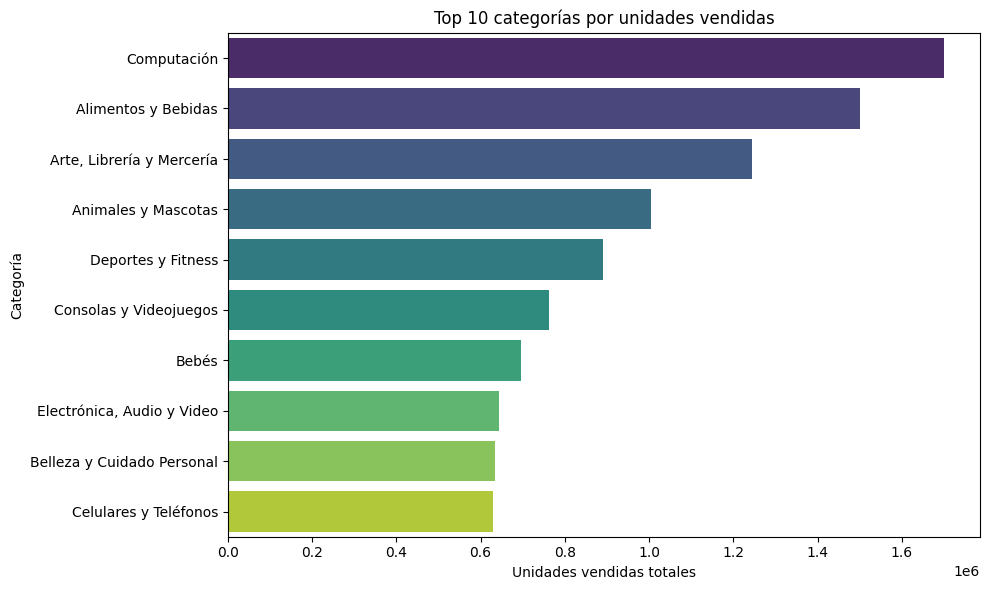

In [20]:
# Grafico categorias mas vendidas
cat_sales = df.groupby("categoria")["cantidad_vendida"].sum().reset_index()
cat_sales = cat_sales.sort_values("cantidad_vendida", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=cat_sales.head(10), x="cantidad_vendida", y="categoria", palette="viridis")
plt.title("Top 10 categorías por unidades vendidas")
plt.xlabel("Unidades vendidas totales")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1597/1862311488.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["año_mes"] = df["fecha_creacion"].dt.to_period("M").astype(str)


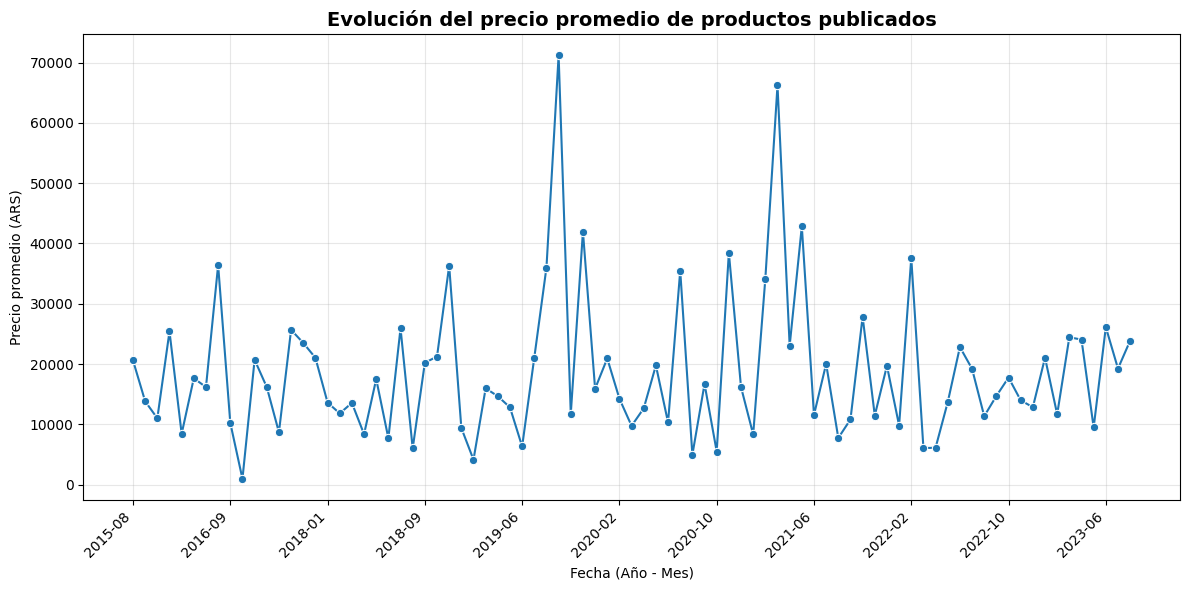

In [21]:
# Evolucion del precio promedio
df["fecha_creacion"] = pd.to_datetime(df["fecha_creacion"], errors="coerce")
df["año_mes"] = df["fecha_creacion"].dt.to_period("M").astype(str)

# Calculo el precio promedio por mes
evolucion_precio = (
    df.groupby("año_mes")["precio"]
    .mean()
    .reset_index()
    .sort_values("año_mes")
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=evolucion_precio,
    x="año_mes",
    y="precio",
    marker="o",
    color="#1f77b4"
)

plt.title("Evolución del precio promedio de productos publicados", fontsize=14, weight="bold")
plt.xlabel("Fecha (Año - Mes)")
plt.ylabel("Precio promedio (ARS)")

plt.xticks(
    ticks=range(0, len(evolucion_precio["año_mes"]), max(1, len(evolucion_precio)//10)),
    labels=evolucion_precio["año_mes"].iloc[::max(1, len(evolucion_precio)//10)],
    rotation=45,
    ha="right"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

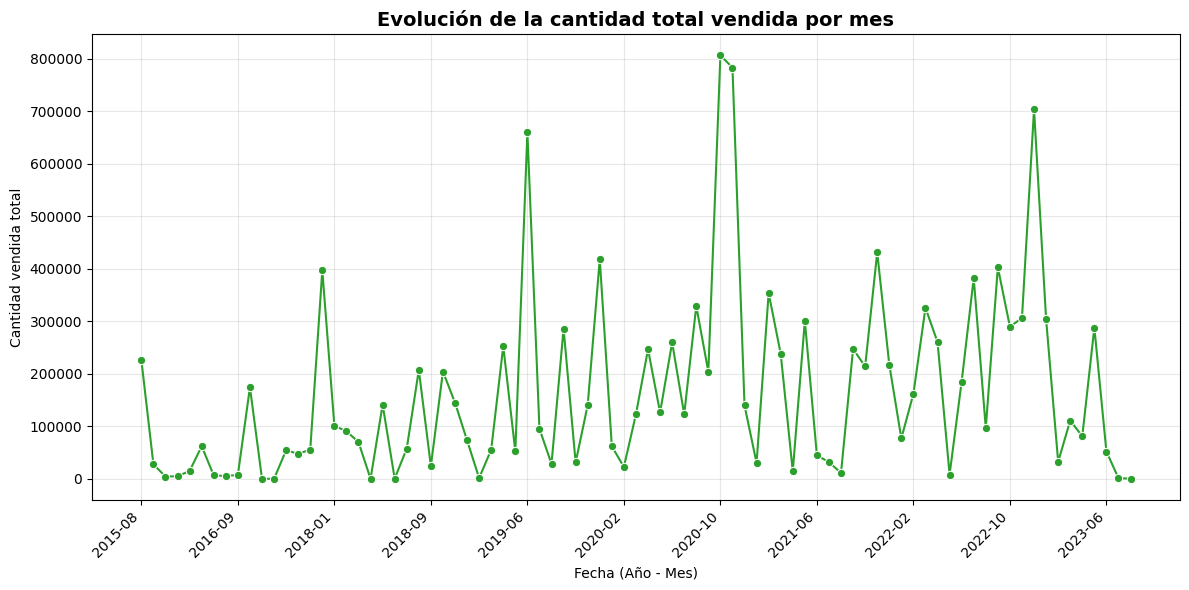

In [22]:
# Cantidad total vendida por mes
evolucion_ventas = (
    df.groupby("año_mes")["cantidad_vendida"]
    .sum()
    .reset_index()
    .sort_values("año_mes")
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=evolucion_ventas,
    x="año_mes",
    y="cantidad_vendida",
    marker="o",
    color="#2ca02c"
)

plt.title("Evolución de la cantidad total vendida por mes", fontsize=14, weight="bold")
plt.xlabel("Fecha (Año - Mes)")
plt.ylabel("Cantidad vendida total")

plt.xticks(
    ticks=range(0, len(evolucion_ventas["año_mes"]), max(1, len(evolucion_ventas)//10)),
    labels=evolucion_ventas["año_mes"].iloc[::max(1, len(evolucion_ventas)//10)],
    rotation=45,
    ha="right"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

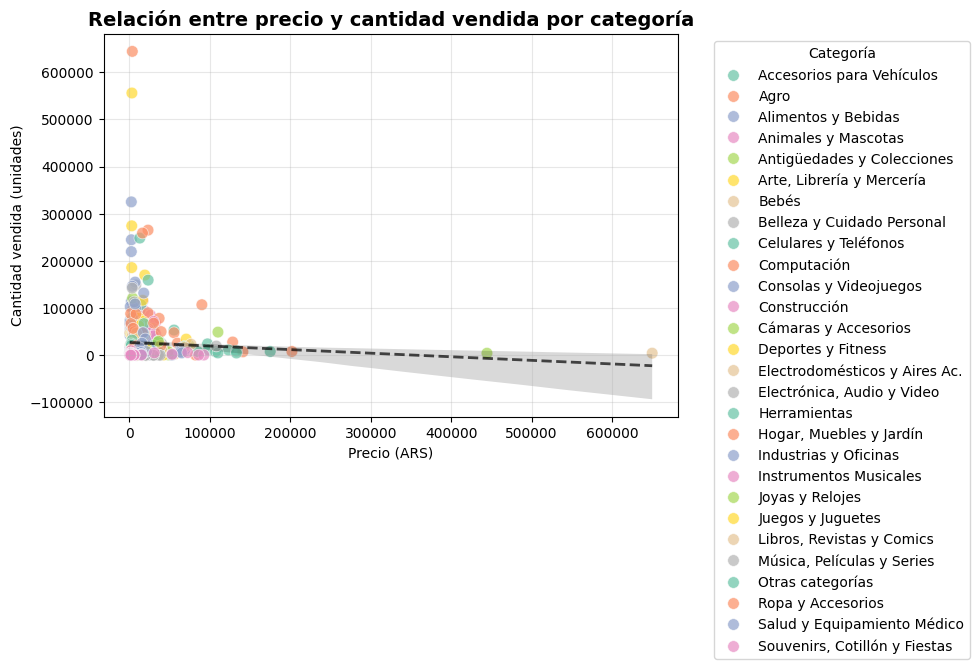

In [23]:
# Relacion entre precio y cantidad vendida
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="precio",
    y="cantidad_vendida",
    hue="categoria",
    alpha=0.7,
    palette="Set2",
    s=70,
    edgecolor="white",
    linewidth=0.5
)

# Agrego línea de tendencia
sns.regplot(
    data=df,
    x="precio",
    y="cantidad_vendida",
    scatter=False,
    color="black",
    line_kws={"linestyle": "dashed", "linewidth": 2, "alpha": 0.7}
)

plt.title("Relación entre precio y cantidad vendida por categoría", fontsize=14, weight="bold")
plt.xlabel("Precio (ARS)")
plt.ylabel("Cantidad vendida (unidades)")
plt.grid(alpha=0.3)
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1597/3876752415.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1597/3876752415.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


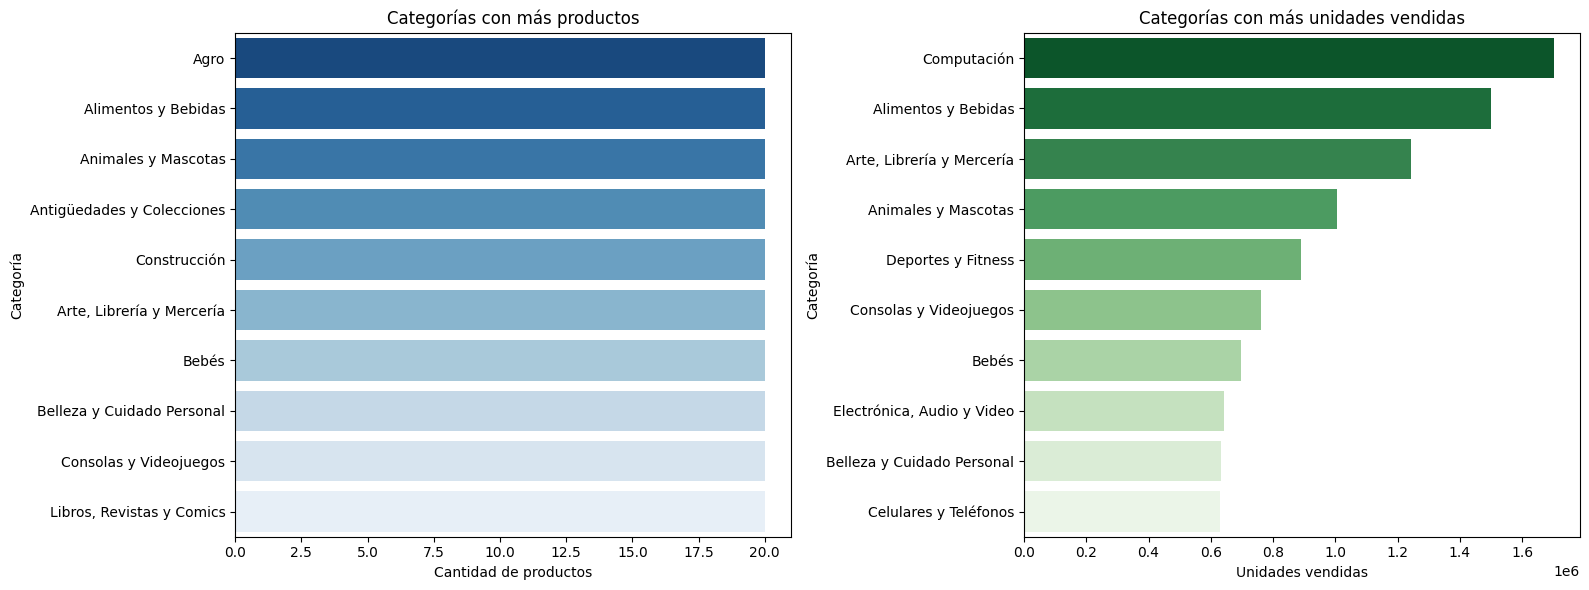

In [24]:
# Categorías con mas productos
cat_count = df["categoria"].value_counts().head(10)

# Categorias con mas ventas
cat_sales = (
    df.groupby("categoria")["cantidad_vendida"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Izquierda: Grafico de categorías con más productos
sns.barplot(
    x=cat_count.values,
    y=cat_count.index,
    palette="Blues_r",
    ax=ax[0]
)
ax[0].set_title("Categorías con más productos")
ax[0].set_xlabel("Cantidad de productos")
ax[0].set_ylabel("Categoría")

# Derecha: Grafico de categorias con más ventas
sns.barplot(
    x=cat_sales.values,
    y=cat_sales.index,
    palette="Greens_r",
    ax=ax[1]
)
ax[1].set_title("Categorías con más unidades vendidas")
ax[1].set_xlabel("Unidades vendidas")
ax[1].set_ylabel("Categoría")

plt.tight_layout()
plt.show()

Conclucion:

En este analisis se observaron los principales patrones de los productos mas vendidos en Mercado Libre. Se identifico que los articulos con mayor volumen de ventas suelen tener precios accesibles, mientras que los productos de precio medio son los que generan los mayores ingresos totales. Tambien se ve que la categoria "Accesorios para vehiculos" concentra gran parte de las ventas del conjunto de datos analizados. Los graficos nos permiten ver como se relacionan el precio, la cantidad vendida y los ingresos. Dicho analisis nos permite ver el comportamiento del mercado y de las tendencias del consumo dentro de la plataforma.

La categoria "Accesorios para vehiculos" es la que mas productos aporta al informe, pero no es la que mas vende. Al analizar la cantidad total de unidades vendidas, "Articulos de computacion" se ubica primero, ya que sus productos tinen una demanda mucho mayor. Esto muestra que la categoria mas numerosa no siempre es la que tiene mayor volumen de ventas.